In [2]:
import os
os.makedirs("results", exist_ok=True)


In [3]:
import subprocess

seeds = [0, 1, 2]
for s in seeds:
    print(f"\nRunning seed {s} ...")
    subprocess.run(f"python src/train_cartpole.py --episodes 500 --seed {s}", shell=True)



Running seed 0 ...

Running seed 1 ...

Running seed 2 ...


In [4]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for s in [0, 1, 2]:
    returns = np.load(f"results/returns_seed{s}.npy")
    plt.plot(returns, alpha=0.7, label=f"seed {s}")

plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('DQN CartPole Learning Curves (3 Seeds)')
plt.legend()
plt.grid(True)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'results/returns_seed0.npy'

<Figure size 1000x600 with 0 Axes>

In [5]:
import os

print("현재 작업 폴더:", os.getcwd())
print("\nresults 폴더 존재?", os.path.exists("results"))

if os.path.exists("results"):
    print("\nresults 폴더 안 파일 목록:")
    print(os.listdir("results"))


현재 작업 폴더: C:\Users\User

results 폴더 존재? True

results 폴더 안 파일 목록:
[]


In [2]:
%cd C:\Users\User\rl-dqn-cartpole


C:\Users\User\rl-dqn-cartpole


In [3]:
import os
print("현재 작업 폴더:", os.getcwd())
print("현재 폴더 안 파일들:", os.listdir())


현재 작업 폴더: C:\Users\User\rl-dqn-cartpole
현재 폴더 안 파일들: ['requirements.txt', 'results', 'src']


In [8]:
import os
os.makedirs("results", exist_ok=True)


In [9]:
print("현재 작업 폴더:", os.getcwd())
print("현재 폴더 안 파일들:", os.listdir())

현재 작업 폴더: C:\Users\User\rl-dqn-cartpole
현재 폴더 안 파일들: ['requirements.txt', 'results', 'src']


In [4]:
import subprocess

seeds = [0, 1, 2]
for s in seeds:
    print(f"\nRunning seed {s} ...")
    subprocess.run(f"python src/train_cartpole.py --episodes 500 --seed {s}", shell=True)



Running seed 0 ...

Running seed 1 ...

Running seed 2 ...


In [5]:
import os

print("현재 작업 폴더:", os.getcwd())
print("현재 폴더 안:", os.listdir())

if os.path.exists("results"):
    print("\nresults 폴더 안:", os.listdir("results"))
else:
    print("\nresults 폴더가 없습니다.")


현재 작업 폴더: C:\Users\User\rl-dqn-cartpole
현재 폴더 안: ['requirements.txt', 'results', 'src']

results 폴더 안: ['dqn_cartpole_seed0.png', 'dqn_cartpole_seed1.png', 'dqn_cartpole_seed2.png', 'returns_seed0.npy', 'returns_seed1.npy', 'returns_seed2.npy']


In [6]:
%cd C:\Users\User\rl-dqn-cartpole

!python src/train_cartpole.py --episodes 50 --seed 0 --save-dir results


C:\Users\User\rl-dqn-cartpole
[Episode   10] Return:   32.0 | Last 10 avg:  32.90
[Episode   20] Return:    9.0 | Last 10 avg:  18.00
[Episode   30] Return:   20.0 | Last 10 avg:  24.20
[Episode   40] Return:   18.0 | Last 10 avg:  23.90
[Episode   50] Return:   12.0 | Last 10 avg:  19.20
Saved returns to results\returns_seed0.npy
Saved plot to results\dqn_cartpole_seed0.png


In [7]:
import os
print(os.listdir("results"))

['dqn_cartpole_seed0.png', 'dqn_cartpole_seed1.png', 'dqn_cartpole_seed2.png', 'returns_seed0.npy', 'returns_seed1.npy', 'returns_seed2.npy']


In [8]:
%cd C:\Users\User\rl-dqn-cartpole

import subprocess

seeds = [0, 1, 2]
for s in seeds:
    print(f"\nRunning seed {s} ...")
    subprocess.run(f"python src/train_cartpole.py --episodes 500 --seed {s} --save-dir results", shell=True)


C:\Users\User\rl-dqn-cartpole

Running seed 0 ...

Running seed 1 ...

Running seed 2 ...


In [9]:
import os

print("현재 폴더:", os.getcwd())
print("results 폴더 안:", os.listdir("results"))


현재 폴더: C:\Users\User\rl-dqn-cartpole
results 폴더 안: ['dqn_cartpole_seed0.png', 'dqn_cartpole_seed1.png', 'dqn_cartpole_seed2.png', 'returns_seed0.npy', 'returns_seed1.npy', 'returns_seed2.npy']


In [10]:
import numpy as np

for s in [0, 1, 2]:
    r = np.load(f"results/returns_seed{s}.npy")
    print(s, len(r))


0 500
1 500
2 500


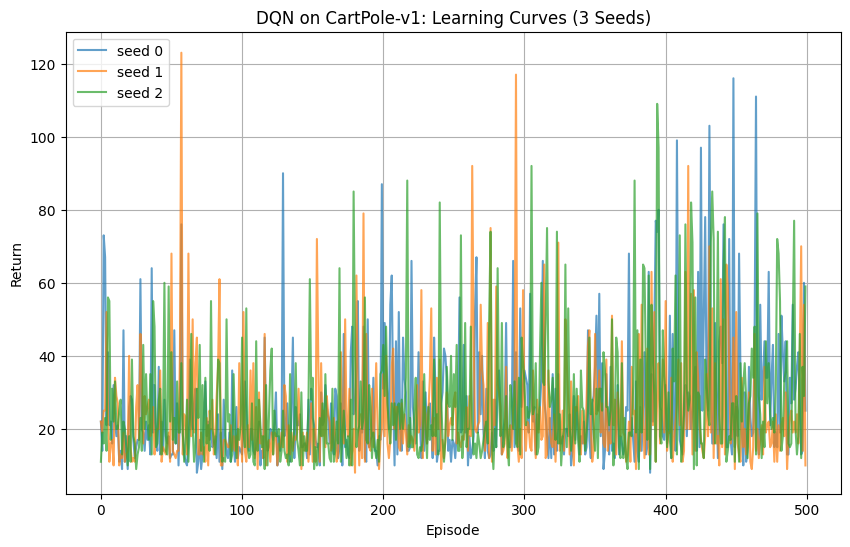

In [11]:
import numpy as np
import matplotlib.pyplot as plt

seeds = [0, 1, 2]

plt.figure(figsize=(10,6))
for s in seeds:
    returns = np.load(f"results/returns_seed{s}.npy")
    plt.plot(returns, alpha=0.7, label=f"seed {s}")

plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('DQN on CartPole-v1: Learning Curves (3 Seeds)')
plt.legend()
plt.grid(True)
plt.show()


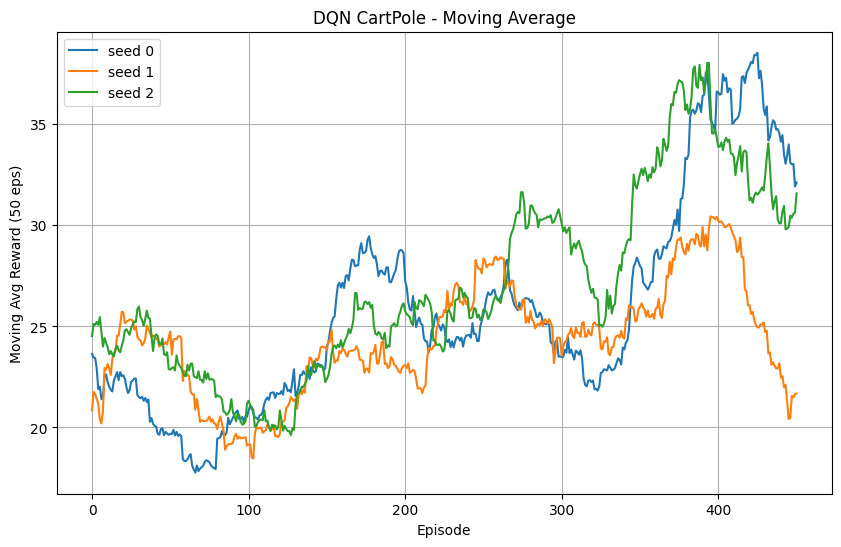

In [12]:
window = 50
plt.figure(figsize=(10,6))

for s in seeds:
    r = np.load(f"results/returns_seed{s}.npy")
    if len(r) >= window:
        avg = np.convolve(r, np.ones(window)/window, mode='valid')
        plt.plot(avg, label=f"seed {s}")

plt.xlabel('Episode')
plt.ylabel(f'Moving Avg Reward ({window} eps)')
plt.title('DQN CartPole - Moving Average')
plt.legend()
plt.grid(True)
plt.show()


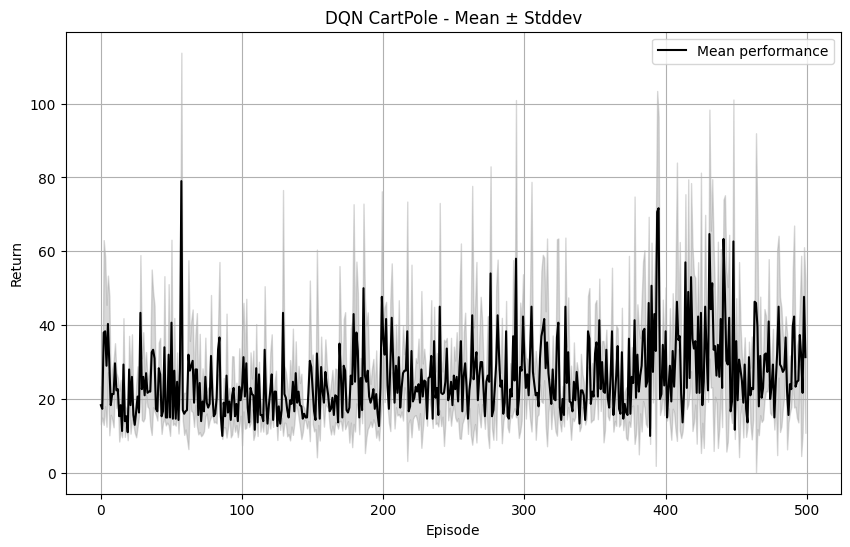

In [13]:
returns_all = [np.load(f"results/returns_seed{s}.npy") for s in seeds]
min_len = min(len(r) for r in returns_all)
returns_all = np.array([r[:min_len] for r in returns_all])

mean = returns_all.mean(axis=0)
std = returns_all.std(axis=0)

plt.figure(figsize=(10,6))
plt.plot(mean, color='black', label='Mean performance')
plt.fill_between(np.arange(min_len), mean-std, mean+std, alpha=0.3, color='gray')

plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('DQN CartPole - Mean ± Stddev')
plt.legend()
plt.grid(True)
plt.show()
